In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

x1=[0.512157422473546, 0.00176884960594392, 0.968577740477047, 0.938192225240928, 0.950745881448564, 0.223265541080513, 0.85130825558051, 0.429871471430102, 0.507872430118519, 0.471521200233533, 0.936866900234523, 0.787901896996771, 0.0290351119247221, 0.533387834128333, 0.328020550676465, 0.529636079347581, 0.171321024982362, 0.733492399558278, 0.15469662211061, 0.319440241071868, 0.53196728229544, 0.76154860299542, 0.221610263168124, 0.412560081062265, 0.289253023992175, 0.360495838749828, 0.830156403232545, 0.126461946356088, 0.402980296436842, 0.87127590400948]
x2=[5.92818885414411, 7.51484862228339, 5.96089933125389, 3.77828174662814, 7.45946218541005, 4.08181794240161, 6.85791951546157, 4.54863474926102, 5.57148479368613, 4.27057349340535, 6.30032896329754, 3.63178278979576, 6.66843532688033, 4.1389603127549, 6.15781404446676, 3.49254295966117, 7.77127644240094, 7.11813882461958, 3.57598699211097, 5.98576665131754, 6.2756659574326, 4.4910200860497, 6.19062859185692, 5.56215832547806, 7.95666922643979, 6.54315089533033, 7.08844316983051, 7.99588124389356, 3.2067487477148, 6.39021384510485]
x3=[0.335100444311287, -0.304805603201893, -1.37162699812855, -2.43897674976302, 1.79767159937651, 2.24417137799168, 0.888616018214949, -1.70769712652717, 0.912846812987788, -1.58537387606711, 1.76525402305305, 2.48939336887052, -1.41729977747456, 1.56551832072423, -1.61707565722042, 2.37625794904525, 0.225085998360977, -0.542134144274935, -0.083272092736459, 0.414591489773141, -1.97562842160366, -0.0846069036786972, -0.786408139819922, 0.951827494550435, 2.36644878110245, 1.58651195555138, -0.378743545388671, 0.243196977217556, 0.944752252635903, 0.346302817604332]
z=[39.3248573384225, 48.7970032234364, 47.2281601297377, 40.5237001826746, 42.0081162924413, 21.8789352822024, 42.4377500156091, 40.433705195274, 35.2217815767165, 38.6374053717622, 36.3143625247446, 19.7771442674903, 49.0694459681493, 25.4995039491343, 47.9134139525684, 19.01695516082, 48.2986802685255, 49.2262154993142, 28.5224165757219, 38.9093477796389, 50.3447780381685, 34.3166252509541, 44.5419960449005, 34.8286018113131, 40.8960570557735, 37.0906983319458, 48.6175028371723, 49.2595422033097, 23.0606953209041, 42.3084097631259]


In [ ]:
# 1. Construimos el dataloader
from torch.utils.data import DataLoader
data=[(np.array([a,b,c]).astype(np.float32),np.float32(d)) for a,b,c,d in zip(x1,x2,x3,z)]
train=DataLoader(data,batch_size=15,shuffle=True)
it=iter(train)
x,y=next(it)
print(x.shape, y.shape)

torch.Size([15, 3]) torch.Size([15])


In [ ]:
# 2. Generar el modelo
modelo=torch.nn.Sequential(
    torch.nn.Linear(3,10),
    torch.nn.ReLU(),
    torch.nn.Linear(10,10),
    torch.nn.ReLU(),
    torch.nn.Linear(10,1),
    torch.nn.ReLU()
)

X=np.array([0.25, 3.5, 0.8])
X=torch.tensor(X).float().unsqueeze(0)
print(X.shape)
y=modelo(X)
print(y.shape)

torch.Size([1, 3])
torch.Size([1, 1])


In [ ]:
# 3. Función de perdida
loss=torch.nn.MSELoss()

# 4. Optimizador
optim=torch.optim.SGD(modelo.parameters(),lr=0.0001, momentum=0.9)

100%|██████████| 50/50 [00:00<00:00, 156.65it/s]


Text(0.5, 1.0, 'Error vs Iteraciones')

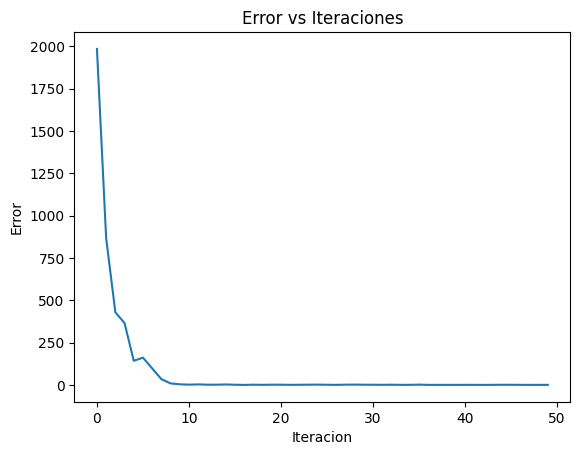

In [ ]:
# 5. Proceso iterativo de entrenamiento
from tqdm import tqdm
err=[]
for i in tqdm(range(50)): #Número de iteraciones en total
  #Para cada uno de los epochs, se itera sobre los datos
  for x,y in train:
    tmp=[]
    y_est=modelo(x.float())
    e=loss(y_est,y.float())
    optim.zero_grad()
    e.backward()
    optim.step()
    tmp.append(e.item())
  err.append(np.mean(tmp))
plt.plot(err)
plt.xlabel('Iteracion')
plt.ylabel('Error')
plt.title('Error vs Iteraciones')


Text(0.5, 1.0, 'z vs z_est')

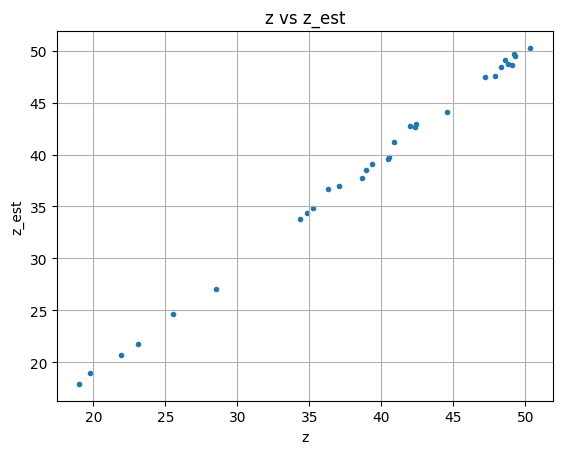

In [ ]:
test=DataLoader(data, batch_size=len(data))
x,z=next(iter(test))
z_est=modelo(x.float())
plt.scatter(z.detach().numpy(),z_est.detach().numpy(), marker='.')
plt.grid()
plt.xlabel('z')
plt.ylabel('z_est')
plt.title('z vs z_est')